In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from medmnist import DermaMNIST

In [4]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=True, size=28)
val_dataset = DermaMNIST(split="val", download=True, size=28)
test_dataset = DermaMNIST(split="test", download=True, size=28)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7


100%|██████████████████████████████████████| 19.7M/19.7M [00:17<00:00, 1.12MB/s]


Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [17]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label[0]) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


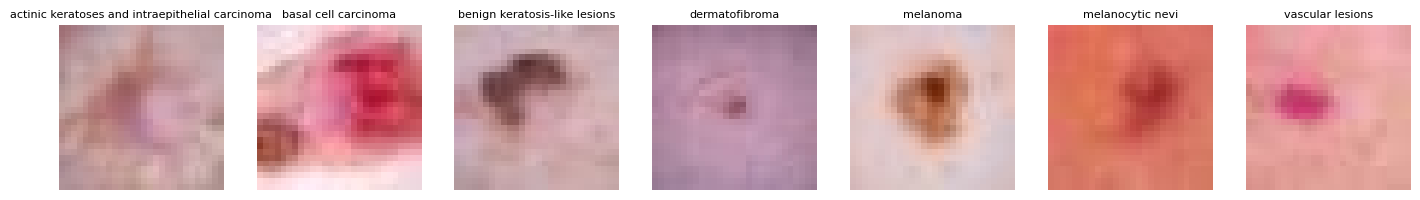

In [19]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label[0])
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [5]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma

In [20]:
img, label = train_dataset[0]
print(np.array(img).shape)
info["n_channels"]

(28, 28, 3)


3

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [22]:
train_dataset = DermaMNIST(
    split="train",
    transform=train_transform,   
    download=True,
    size=28
)

val_dataset = DermaMNIST(
    split="val",
    transform=test_transform,
    download=True,
    size=28
)

test_dataset = DermaMNIST(
    split="test",
    transform=test_transform,
    download=True,
    size=28
)

In [23]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

n_classes = len(train_dataset.info["label"])

In [48]:
def get_efficientnet_b0():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def get_efficientnet_b1():
    model = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [40]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [39]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [49]:
effnet_b0 = get_efficientnet_b0()
effnet_b0 = train_model(effnet_b0, train_loader, val_loader, epochs=10)

test_acc_b0 = evaluate(effnet_b0, test_loader)
print(f"EfficientNet-B0 Test Accuracy: {test_acc_b0:.4f}")

Epoch 1/10 | Loss: 114.6914 | Val Acc: 0.6391
Epoch 2/10 | Loss: 97.3600 | Val Acc: 0.7198
Epoch 3/10 | Loss: 88.8296 | Val Acc: 0.7268
Epoch 4/10 | Loss: 85.2060 | Val Acc: 0.7278
Epoch 5/10 | Loss: 81.8075 | Val Acc: 0.7507
Epoch 6/10 | Loss: 77.9384 | Val Acc: 0.7517
Epoch 7/10 | Loss: 74.9071 | Val Acc: 0.7717
Epoch 8/10 | Loss: 72.4241 | Val Acc: 0.7388
Epoch 9/10 | Loss: 70.6647 | Val Acc: 0.7777
Epoch 10/10 | Loss: 70.4178 | Val Acc: 0.7677
EfficientNet-B0 Test Accuracy: 0.7641


In [50]:
effnet_b1 = get_efficientnet_b1()
effnet_b1 = train_model(effnet_b1, train_loader, val_loader, epochs=10)

test_acc_b1 = evaluate(effnet_b1, test_loader)
print(f"EfficientNet-B1 Test Accuracy: {test_acc_b1:.4f}")

Epoch 1/10 | Loss: 112.8690 | Val Acc: 0.6979
Epoch 2/10 | Loss: 88.8039 | Val Acc: 0.7278
Epoch 3/10 | Loss: 84.7984 | Val Acc: 0.7308
Epoch 4/10 | Loss: 79.3475 | Val Acc: 0.7328
Epoch 5/10 | Loss: 76.8389 | Val Acc: 0.7468
Epoch 6/10 | Loss: 76.9527 | Val Acc: 0.7288
Epoch 7/10 | Loss: 77.4253 | Val Acc: 0.7488
Epoch 8/10 | Loss: 74.0377 | Val Acc: 0.7428
Epoch 9/10 | Loss: 71.9056 | Val Acc: 0.7757
Epoch 10/10 | Loss: 70.1808 | Val Acc: 0.7637
EfficientNet-B1 Test Accuracy: 0.7596


In [51]:
def compute_auc(model, loader, split):
    model.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.append(labels.cpu())
            y_score.append(probs.cpu())

    y_true = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()

    evaluator = Evaluator("dermamnist", split)
    metrics = evaluator.evaluate(y_score)

    return metrics

In [52]:
val_auc_b0 = compute_auc(effnet_b0, val_loader, split="val")
test_auc_b0 = compute_auc(effnet_b0, test_loader, split="test")

print("EfficientNet-B0 Val AUC:", val_auc_b0)
print("EfficientNet-B0 Test AUC:", test_auc_b0)

EfficientNet-B0 Val AUC: Metrics(AUC=0.9293478903989728, ACC=0.7676969092721835)
EfficientNet-B0 Test AUC: Metrics(AUC=0.9207578134412323, ACC=0.7640897755610973)


In [53]:
val_auc_b1 = compute_auc(effnet_b1, val_loader, split="val")
test_auc_b1 = compute_auc(effnet_b1, test_loader, split="test")

print("EfficientNet-B1 Val AUC:", val_auc_b1)
print("EfficientNet-B1 Test AUC:", test_auc_b1)

EfficientNet-B1 Val AUC: Metrics(AUC=0.9126036080300465, ACC=0.7637088733798604)
EfficientNet-B1 Test AUC: Metrics(AUC=0.9179924095069145, ACC=0.7596009975062344)


In [54]:
os.makedirs("./results/models", exist_ok=True)
os.makedirs("./results/predictions", exist_ok=True)

torch.save(effnet_b0.state_dict(), "results/models/effnet_b0.pth")
torch.save(effnet_b1.state_dict(), "results/models/effnet_b1.pth")

def get_outputs(model, loader):
    model.eval()
    
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return all_labels, all_preds, all_probs

def save_split(model, loader, filename):
    labels, preds, probs = get_outputs(model, loader)
    
    df = pd.DataFrame(probs) 
    df["true_label"] = labels
    df["pred_label"] = preds
    
    df.to_csv(filename, index=False)

save_split(effnet_b0, train_loader, "results/predictions/effnet_b0_train.csv")
save_split(effnet_b0, val_loader,   "results/predictions/effnet_b0_val.csv")
save_split(effnet_b0, test_loader,  "results/predictions/effnet_b0_test.csv")

save_split(effnet_b1, train_loader, "results/predictions/effnet_b1_train.csv")
save_split(effnet_b1, val_loader,   "results/predictions/effnet_b1_val.csv")
save_split(effnet_b1, test_loader,  "results/predictions/effnet_b1_test.csv")

In [55]:
effnet_b0 = get_efficientnet_b0()
effnet_b0.load_state_dict(torch.load("results/models/effnet_b0.pth"))
effnet_b0.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.squeeze().long().to(device)

with torch.no_grad():
    outputs = effnet_b0(images)
    preds = torch.argmax(outputs, dim=1)

print("Preds: ", preds[:10].cpu().numpy())
print("Labels:", labels[:10].cpu().numpy())

Preds:  [5 0 2 5 5 5 5 4 5 2]
Labels: [5 3 4 0 5 5 5 4 5 2]
